# Your First Sampler: Block Gibbs on a Grid

This notebook explains how **Gibbs sampling** works, why we need **block** updates for efficient GPU execution, and walks through building a complete sampling pipeline from scratch using hamon's Ising model APIs.

By the end you will:
- Understand the Gibbs sampling algorithm and its convergence properties
- Know why block updates are essential for GPU-accelerated sampling
- Use **graph coloring** to identify independent blocks
- Build and run an Ising model sampling program step-by-step
- Visualize how temperature controls the sampled configurations

## What is Gibbs sampling?

Given an energy-based model over $N$ variables, we want to draw samples from the Boltzmann distribution $P(x) \propto \exp(-E(x))$. When $N$ is large, we can't enumerate all states, so we use **Markov chain Monte Carlo (MCMC)**.

**Gibbs sampling** is one of the simplest MCMC methods:

1. Start with an initial configuration $x^{(0)}$
2. For each step $t$:
   - Pick a variable $x_i$
   - Sample $x_i$ from its **conditional distribution** $P(x_i \mid x_{\setminus i})$, holding all other variables fixed
3. After enough steps, the samples approximate the target distribution

The conditional distribution only depends on $x_i$'s **neighbors** in the factor graph. This locality makes Gibbs sampling natural for graphical models.

### The problem with sequential updates

Updating one variable at a time means $N$ sequential steps per sweep. GPUs are designed for massive parallelism — they want thousands of operations running simultaneously. Sequential Gibbs is a terrible fit.

The solution: **block Gibbs sampling**.

## Block Gibbs sampling and graph coloring

If two variables $x_i$ and $x_j$ are **conditionally independent** given all others (i.e., they share no factor), we can update them simultaneously without violating the Gibbs sampling invariant.

Finding the largest sets of mutually independent variables is exactly the **graph coloring** problem on the interaction graph:
- Each color class is a set of variables with no edges between them
- All variables in a color class can be updated in parallel
- We cycle through color classes sequentially

For a 2D grid, this gives the familiar **checkerboard pattern**: 2 colors, so each sweep requires only 2 sequential steps regardless of grid size.

Graph coloring uses 2 colors


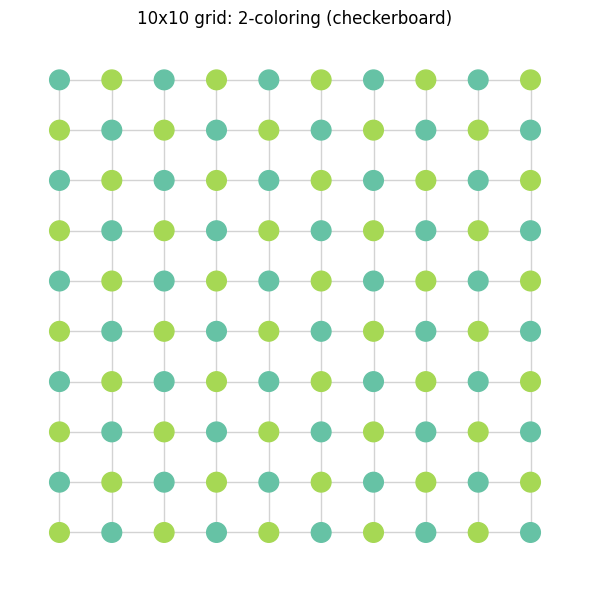

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# Build a 10x10 grid graph
ROWS, COLS = 10, 10
G = nx.grid_2d_graph(ROWS, COLS)

# Graph coloring
coloring = nx.coloring.greedy_color(G, strategy="DSATUR")
n_graph_colors = max(coloring.values()) + 1
print(f"Graph coloring uses {n_graph_colors} colors")

# Visualize
fig, ax = plt.subplots(figsize=(6, 6))
pos = {(r, c): (c, -r) for r in range(ROWS) for c in range(COLS)}
node_colors = [coloring[n] for n in G.nodes()]
cmap = plt.cm.Set2
nx.draw(
    G,
    pos,
    ax=ax,
    with_labels=False,
    node_color=node_colors,
    cmap=cmap,
    vmin=0,
    vmax=n_graph_colors,
    node_size=200,
    edge_color="lightgray",
    width=1,
)
ax.set_title(f"10x10 grid: {n_graph_colors}-coloring (checkerboard)")
plt.tight_layout()
plt.show()

All nodes of the same color can be updated simultaneously — this is the essence of block Gibbs sampling. On a 10×10 grid that's 50 parallel updates per step instead of 100 sequential ones. The advantage grows with system size.

## Building a sampling program step by step

Let's build a complete Ising model sampling program using hamon's core APIs. The **Ising model** has binary spin variables $s_i \in \{-1, +1\}$ with energy:

$$E(s) = -\beta \left( \sum_i b_i s_i + \sum_{(i,j)} J_{ij} s_i s_j \right)$$

In [2]:
from hamon import SpinNode, Block, SamplingSchedule, sample_states
from hamon.models.ising import IsingEBM, IsingSamplingProgram, hinton_init

# Step 1: Create SpinNode instances (one per grid site)
nodes = [[SpinNode() for _ in range(COLS)] for _ in range(ROWS)]
flat_nodes = [nodes[r][c] for r in range(ROWS) for c in range(COLS)]

# Step 2: Define edges (nearest-neighbor couplings)
edge_list = []
for r in range(ROWS):
    for c in range(COLS):
        if c + 1 < COLS:
            edge_list.append((nodes[r][c], nodes[r][c + 1]))
        if r + 1 < ROWS:
            edge_list.append((nodes[r][c], nodes[r + 1][c]))

# Step 3: Set model parameters
n_sites = ROWS * COLS
n_edges = len(edge_list)
biases = jnp.zeros(n_sites)  # no external field
weights = jnp.ones(n_edges) * 1.0  # uniform ferromagnetic coupling
beta = jnp.array(0.5)  # moderate temperature

# Step 4: Build the IsingEBM
ebm = IsingEBM(flat_nodes, edge_list, biases, weights, beta)

print(f"Model: {n_sites} spins, {n_edges} couplings, beta = {float(beta)}")

Model: 100 spins, 180 couplings, beta = 0.5


In [3]:
# Step 5: Partition nodes into free blocks using graph coloring
color_groups = [[] for _ in range(n_graph_colors)]
for (r, c), color in coloring.items():
    color_groups[color].append(nodes[r][c])

free_blocks = [Block(group) for group in color_groups]

# Step 6: Build the sampling program
program = IsingSamplingProgram(ebm, free_blocks, clamped_blocks=[])

# Step 7: Initialize with Hinton initialization (sample from marginal bias)
key = jax.random.key(0)
key, init_key = jax.random.split(key)
init_state = hinton_init(init_key, ebm, free_blocks, ())

# Step 8: Define the sampling schedule and collect samples
schedule = SamplingSchedule(n_warmup=200, n_samples=500, steps_per_sample=2)

key, sample_key = jax.random.split(key)
obs_block = Block(flat_nodes)
samples = sample_states(sample_key, program, schedule, init_state, [], [obs_block])
samples = samples[0]  # shape: (500, 100)

print(f"Collected {samples.shape[0]} samples of {samples.shape[1]} spins")

Collected 500 samples of 100 spins


## Visualizing the results

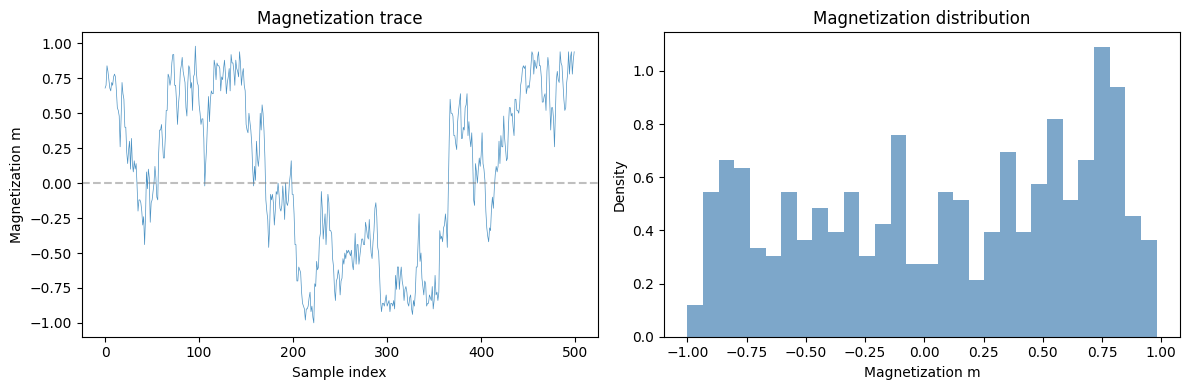

In [4]:
# Convert boolean (True=+1, False=-1) to spin values
spin_samples = 2 * samples.astype(jnp.float32) - 1

# Magnetization per sample: m = mean(s_i)
magnetization = jnp.mean(spin_samples, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Trace plot
axes[0].plot(magnetization, linewidth=0.5, alpha=0.8)
axes[0].set_xlabel("Sample index")
axes[0].set_ylabel("Magnetization m")
axes[0].set_title("Magnetization trace")
axes[0].axhline(0, color="gray", linestyle="--", alpha=0.5)

# Histogram
axes[1].hist(
    np.array(magnetization), bins=30, density=True, alpha=0.7, color="steelblue"
)
axes[1].set_xlabel("Magnetization m")
axes[1].set_ylabel("Density")
axes[1].set_title("Magnetization distribution")

plt.tight_layout()
plt.show()

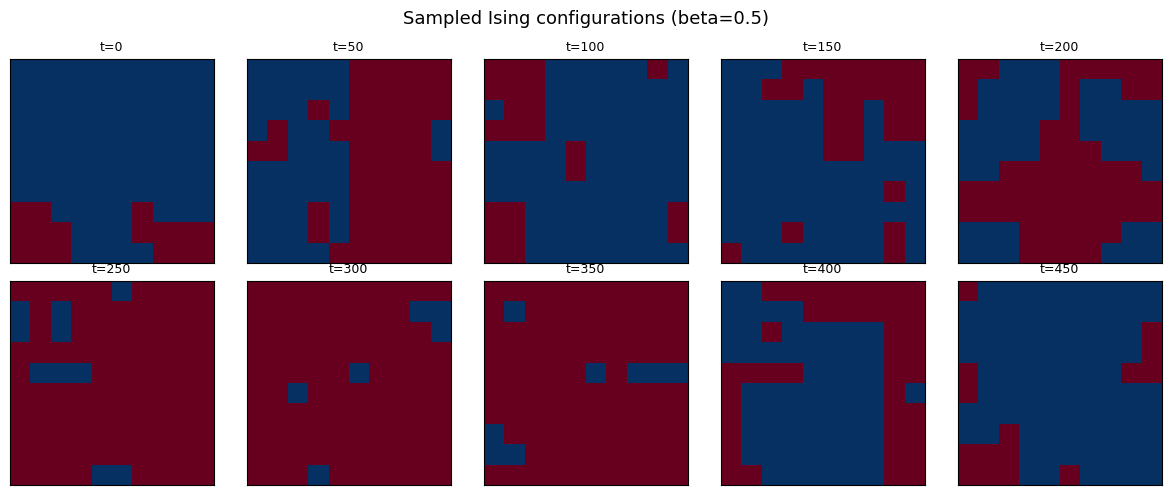

In [5]:
# Show some sampled configurations
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for idx, ax in enumerate(axes.flat):
    sample_idx = idx * (len(samples) // 10)
    grid = np.array(samples[sample_idx]).reshape(ROWS, COLS).astype(float)
    ax.imshow(grid, cmap="RdBu", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(f"t={sample_idx}", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(f"Sampled Ising configurations (beta={float(beta)})", fontsize=13)
plt.tight_layout()
plt.show()

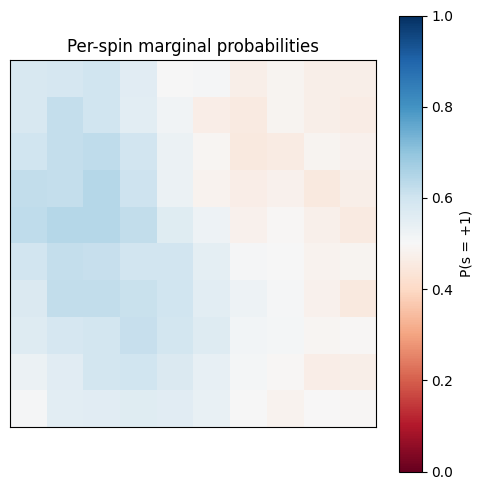

In [6]:
# Per-spin marginal probability P(s_i = +1)
marginals = jnp.mean(samples.astype(jnp.float32), axis=0).reshape(ROWS, COLS)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(marginals, cmap="RdBu", vmin=0, vmax=1, interpolation="nearest")
plt.colorbar(im, ax=ax, label="P(s = +1)")
ax.set_title("Per-spin marginal probabilities")
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

With zero bias and symmetric ferromagnetic coupling, each spin is equally likely to be +1 or -1, so the marginals should be near 0.5 everywhere. The configurations, however, show local correlations — clusters of aligned spins.

## The effect of temperature

Let's sweep across several values of $\beta$ to see how temperature affects the sampled configurations.

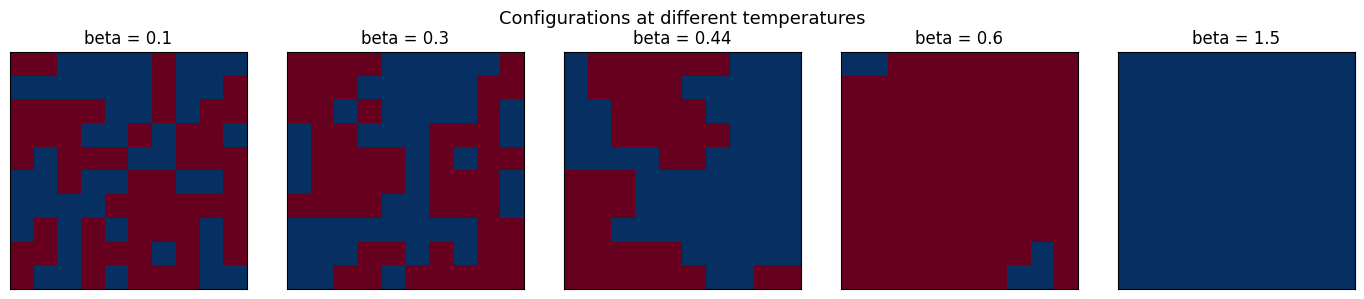

In [7]:
beta_values = [0.1, 0.3, 0.44, 0.6, 1.5]
all_magnetizations = []

fig, axes = plt.subplots(1, len(beta_values), figsize=(14, 3))

for ax, b_val in zip(axes, beta_values):
    # Build model at this temperature
    ebm_b = IsingEBM(flat_nodes, edge_list, biases, weights, jnp.array(b_val))
    prog_b = IsingSamplingProgram(ebm_b, free_blocks, [])

    key, k1, k2 = jax.random.split(key, 3)
    init_b = hinton_init(k1, ebm_b, free_blocks, ())
    sched_b = SamplingSchedule(n_warmup=300, n_samples=200, steps_per_sample=2)
    samp_b = sample_states(k2, prog_b, sched_b, init_b, [], [obs_block])[0]

    # Show last configuration
    grid = np.array(samp_b[-1]).reshape(ROWS, COLS).astype(float)
    ax.imshow(grid, cmap="RdBu", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(f"beta = {b_val}")
    ax.set_xticks([])
    ax.set_yticks([])

    # Track magnetization
    spins = 2 * samp_b.astype(jnp.float32) - 1
    m = jnp.mean(jnp.abs(jnp.mean(spins, axis=1)))
    all_magnetizations.append((b_val, float(m)))

fig.suptitle("Configurations at different temperatures", fontsize=13)
plt.tight_layout()
plt.show()

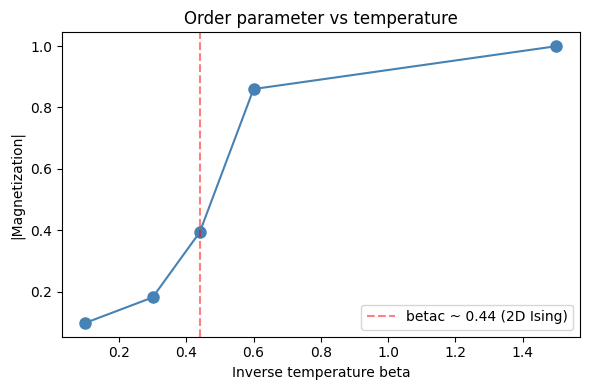

In [8]:
# Plot |m| vs beta
betas_plot, mags_plot = zip(*all_magnetizations)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(betas_plot, mags_plot, "o-", color="steelblue", markersize=8)
ax.axvline(
    0.4407, color="red", linestyle="--", alpha=0.5, label="betac ~ 0.44 (2D Ising)"
)
ax.set_xlabel("Inverse temperature beta")
ax.set_ylabel("|Magnetization|")
ax.set_title("Order parameter vs temperature")
ax.legend()
plt.tight_layout()
plt.show()

At low $\beta$ (high temperature), the system is **disordered** — spins are nearly random and the magnetization is near zero. At high $\beta$ (low temperature), the system **orders** — large domains of aligned spins form and the magnetization is large.

The transition happens near the **critical point** $\beta_c \approx 0.44$ for the 2D square lattice Ising model (the exact Onsager solution). We'll study this phase transition in detail in a later notebook.

## Clamped variables and conditional sampling

Sometimes we want to **fix** (clamp) some variables and sample the rest conditioned on them. This is useful for:
- Computing conditional distributions
- Modeling boundary conditions in physics
- The positive phase of Boltzmann machine training

Let's clamp the boundary spins of our grid to +1 and sample the interior.

In [9]:
# Separate boundary and interior nodes
boundary_nodes = []
interior_nodes = []
for r in range(ROWS):
    for c in range(COLS):
        if r == 0 or r == ROWS - 1 or c == 0 or c == COLS - 1:
            boundary_nodes.append(nodes[r][c])
        else:
            interior_nodes.append(nodes[r][c])

# Graph-color only the interior for free blocks
interior_set = set(id(n) for n in interior_nodes)
G_interior = nx.grid_2d_graph(ROWS, COLS)
# Remove boundary nodes from graph
boundary_coords = [
    (r, c)
    for r in range(ROWS)
    for c in range(COLS)
    if r == 0 or r == ROWS - 1 or c == 0 or c == COLS - 1
]
G_interior.remove_nodes_from(boundary_coords)

interior_coloring = nx.coloring.greedy_color(G_interior, strategy="DSATUR")
n_interior_colors = max(interior_coloring.values()) + 1 if interior_coloring else 1

interior_color_groups = [[] for _ in range(n_interior_colors)]
for (r, c), color in interior_coloring.items():
    interior_color_groups[color].append(nodes[r][c])

free_blocks_cond = [Block(g) for g in interior_color_groups]
clamped_blocks = [Block(boundary_nodes)]

# Build conditional sampling program (beta=0.6 for visible ordering)
ebm_cond = IsingEBM(flat_nodes, edge_list, biases, weights, jnp.array(0.6))
program_cond = IsingSamplingProgram(ebm_cond, free_blocks_cond, clamped_blocks)

# Clamp boundary to all +1 (True in boolean representation)
clamp_data = [jnp.ones(len(boundary_nodes), dtype=jnp.bool_)]

# Initialize interior randomly
key, k1, k2 = jax.random.split(key, 3)
init_interior = hinton_init(k1, ebm_cond, free_blocks_cond, ())

schedule_cond = SamplingSchedule(n_warmup=0, n_samples=200, steps_per_sample=2)
obs_all = Block(flat_nodes)
cond_samples = sample_states(
    k2, program_cond, schedule_cond, init_interior, clamp_data, [obs_all]
)[0]

print(f"Boundary nodes: {len(boundary_nodes)}, Interior nodes: {len(interior_nodes)}")
print(f"Collected {cond_samples.shape[0]} conditional samples")

Boundary nodes: 36, Interior nodes: 64
Collected 200 conditional samples


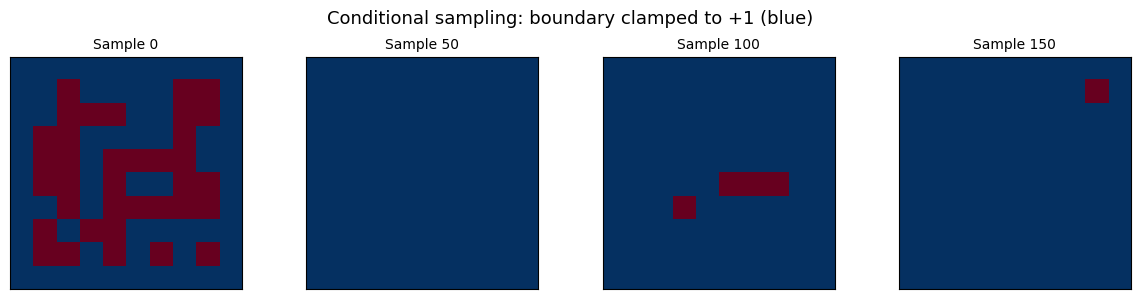

In [10]:
# Visualize: boundary clamped at +1, interior sampled
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for idx, ax in enumerate(axes):
    sample_idx = idx * (len(cond_samples) // 4)
    grid = np.array(cond_samples[sample_idx]).reshape(ROWS, COLS).astype(float)
    ax.imshow(grid, cmap="RdBu", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(f"Sample {sample_idx}", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("Conditional sampling: boundary clamped to +1 (blue)", fontsize=13)
plt.tight_layout()
plt.show()

The boundary spins (clamped to +1) act as a ferromagnetic boundary condition, biasing the interior spins toward +1. You can see the influence of the boundary decaying toward the center of the grid.

## Summary

- **Gibbs sampling** updates variables from their conditional distributions
- **Block Gibbs** updates independent sets in parallel — essential for GPU efficiency
- **Graph coloring** determines which variables form independent blocks
- hamon's `IsingEBM` + `IsingSamplingProgram` provide a complete pipeline: model → blocks → program → samples
- **Temperature** ($\beta$) controls order vs disorder
- **Clamped blocks** enable conditional sampling with fixed boundary conditions

Next up: we'll explore the Ising model in more depth — its physics, the high-level `ising_sample` API, and how to compute physical observables from samples.